In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from CMAPSS.dataset import create_windows
import numpy as np
from models.auto_encoders import SimpleTransformerTriplet
from torch.utils.data import DataLoader
from CMAPSS.dataset import TripletWindowDataset
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Load and prepare data
torch.manual_seed(16976296098443334824)
dataset_name = 'FD001'
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

dataset_train = np.loadtxt(f'../data/train_{dataset_name}.txt')
dataset_test = np.loadtxt(f'../data/test_{dataset_name}.txt')
dataset_test_RUL = np.loadtxt(f'../data/RUL_{dataset_name}.txt')

train_data = np.hstack((
    dataset_train[:, 0].reshape(-1, 1),
    dataset_train[:, 1].reshape(-1, 1),
    dataset_train[:, 5:]
))

test_data = np.hstack((
    dataset_test[:, 0].reshape(-1, 1),
    dataset_test[:, 1].reshape(-1, 1),
    dataset_test[:, 5:]
))

# Create windows
window_size = 10
R_early_train = 0
X_train, train_rul_labels, train_unit_ids = create_windows(
    train_data, window_size=window_size, threshold=R_early_train
)

X_test, test_rul_labels, test_unit_ids = create_windows(
    test_data, window_size=window_size, threshold=R_early_train,
    dataset_test_RUL=dataset_test_RUL
)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create datasets with prototype support
triplet_dataset = TripletWindowDataset(
    X_train_scaled, train_rul_labels, train_unit_ids,
    margin=10, health_margin=20, n_initial_prototypes=8, n_failure_prototypes=8
) # margin=10, hm=20

triplet_dataset_test = TripletWindowDataset(
    X_test_scaled, test_rul_labels, test_unit_ids,
    margin=10, health_margin=20, n_initial_prototypes=8, n_failure_prototypes=0
)

# Create dataloaders with multiple workers
batch_size = 256  # Increased batch size
num_workers = 64 if device == 'cuda' else 0

triplet_loader = DataLoader(
    triplet_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True
)
test_triplet_loader = DataLoader(
    triplet_dataset_test, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True
)

# Initialize model
input_dim = X_train_scaled.shape[1]
latent_dim = 4
model = SimpleTransformerTriplet(input_dim, latent_dim=latent_dim, d_model=32, nhead=8, num_layers=4, dropout=0.1).to(device)

# Use more efficient optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01, betas=(0.9, 0.98))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

# Training configuration
num_epochs = 150
alpha = 1  # Triplet loss weight
beta = 1   # Prototype loss weight
margin = 1.0


Using device: mps


In [4]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 237846
Trainable parameters: 237846


In [9]:
# Track losses
train_losses, train_recon_losses, train_trip_losses, train_proto_losses = [], [], [], []
test_losses, test_recon_losses, test_trip_losses, test_proto_losses = [], [], [], []

best_test_loss = float('inf')
best_model_wts = None

In [ ]:
from models.auto_encoders import train_epoch, evaluate_model

print("Starting training...")
for epoch in range(200):

    current_beta = max(0.3 * (0.95 ** epoch), 0.05)

    # Training
    train_metrics = train_epoch(model, triplet_loader, optimizer, device, alpha, current_beta, margin)
    avg_train_loss, avg_train_recon, avg_train_trip, avg_train_proto = train_metrics

    # Evaluation
    test_metrics = evaluate_model(model, test_triplet_loader, device, alpha, current_beta, margin)
    avg_test_loss, avg_test_recon, avg_test_trip, avg_test_proto = test_metrics

    # Store metrics
    train_losses.append(avg_train_loss)
    train_recon_losses.append(avg_train_recon)
    train_trip_losses.append(avg_train_trip)
    train_proto_losses.append(avg_train_proto)

    test_losses.append(avg_test_loss)
    test_recon_losses.append(avg_test_recon)
    test_trip_losses.append(avg_test_trip)
    test_proto_losses.append(avg_test_proto)

    scheduler.step()

    # Save best model
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        best_model_wts = model.state_dict().copy()
        print(f'>>> Best model at epoch {epoch+1} (Test Loss: {best_test_loss:.4f})')

    # Print progress
    if (epoch + 1) % 20 == 0 or True:
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Recon: {avg_train_recon:.4f} | '
              f'Trip: {avg_train_trip:.4f} | '
              f'Proto: {avg_train_proto:.4f} || '
              f'Test Loss: {avg_test_loss:.4f} | '
              f'Recon: {avg_test_recon:.4f} | '
              f'Trip: {avg_test_trip:.4f} | '
              f'Proto: {avg_test_proto:.4f}')

# Restore best model
#model.load_state_dict(best_model_wts)
print(f'\nTraining complete. Best Test Loss: {best_test_loss:.4f}')

Starting training...
Epoch 161/150: Train Loss: 0.4981 | Recon: 0.0977 | Trip: 0.3850 | Proto: 0.3069 || Test Loss: 0.5044 | Recon: 0.0942 | Trip: 0.3959 | Proto: 0.2852
Epoch 162/150: Train Loss: 0.4909 | Recon: 0.0985 | Trip: 0.3810 | Proto: 0.2267 || Test Loss: 0.5372 | Recon: 0.0948 | Trip: 0.4307 | Proto: 0.2345
Epoch 163/150: Train Loss: 0.5223 | Recon: 0.0999 | Trip: 0.4095 | Proto: 0.2595 || Test Loss: 0.5952 | Recon: 0.0966 | Trip: 0.4871 | Proto: 0.2278
Epoch 164/150: Train Loss: 0.5092 | Recon: 0.0995 | Trip: 0.3955 | Proto: 0.2844 || Test Loss: 0.4502 | Recon: 0.0948 | Trip: 0.3426 | Proto: 0.2552
Epoch 165/150: Train Loss: 0.4945 | Recon: 0.0989 | Trip: 0.3836 | Proto: 0.2383 || Test Loss: 0.5789 | Recon: 0.0946 | Trip: 0.4697 | Proto: 0.2920


In [ ]:
model.load_state_dict(best_model_wts)

In [ ]:
torch.save(model.state_dict(), f=f"{dataset_name}_z{latent_dim}_w{window_size}_v2.pth")
model.eval()

In [6]:
# 1. Recreate your model architecture #_w{window_size}
state_dict = torch.load(f=f"../results/{dataset_name}_z{latent_dim}_w{window_size}_a0.5_b0.5_e500_20260326_204213.pth", map_location=torch.device('cpu'), weights_only=True)
model.load_state_dict(state_dict)
model = model.to(device)
#model.eval()


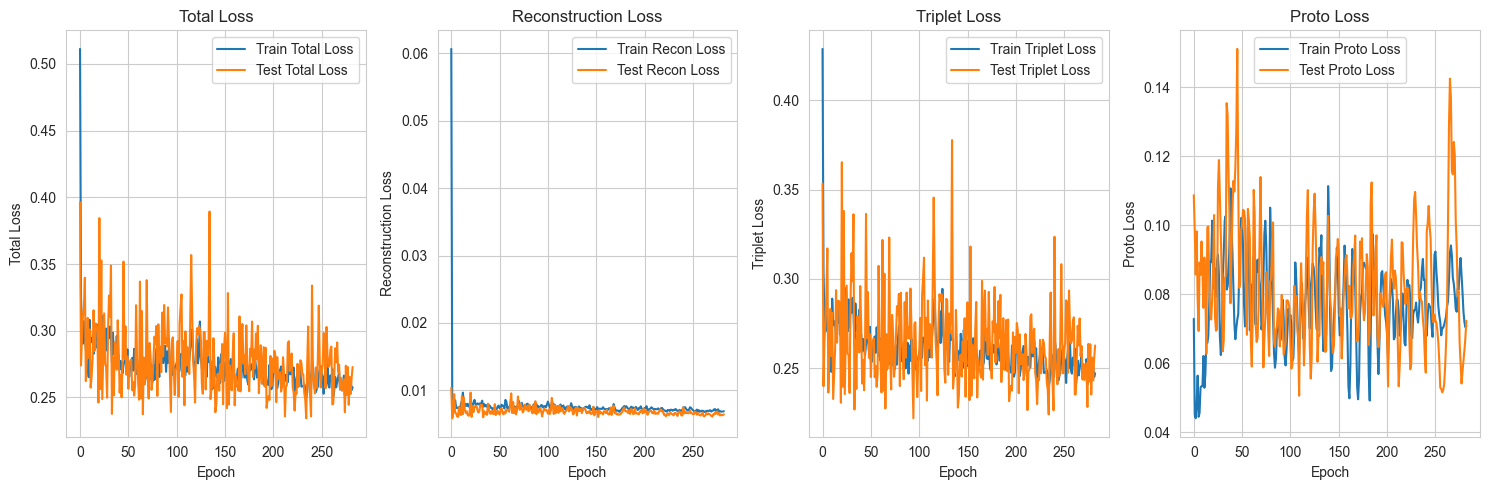

In [22]:
import matplotlib.pyplot as plt

# Plotting the losses
plt.figure(figsize=(15, 5))

# Total Loss
plt.subplot(1, 4, 1)
plt.plot(train_losses, label='Train Total Loss')
plt.plot(test_losses, label='Test Total Loss')  # Should be fixed now
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)

# Reconstruction Loss
plt.subplot(1, 4, 2)
plt.plot(train_recon_losses, label='Train Recon Loss')
plt.plot(test_recon_losses, label='Test Recon Loss')  # Remove .cpu() - they're already floats
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.grid(True)

# Triplet Loss
plt.subplot(1, 4, 3)
plt.plot(train_trip_losses, label='Train Triplet Loss')  # Remove .cpu()
plt.plot(test_trip_losses, label='Test Triplet Loss')    # Remove .cpu()
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Triplet Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(train_proto_losses, label='Train Proto Loss')  # Remove .cpu()
plt.plot(test_proto_losses, label='Test Proto Loss')    # Remove .cpu()
plt.xlabel('Epoch')
plt.ylabel('Proto Loss')
plt.title('Proto Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
from latent_his.extract_latent import extract_latent_representations

model.to(device)

# Usage with your transformer model:
model.eval()
with torch.no_grad():
    # Get latent vectors for training data
    z_train = extract_latent_representations(model, X_train_scaled, device)

    # Get latent vectors for test data
    z_test = extract_latent_representations(model, X_test_scaled, device)

# Scale latent vectors (optional - depends on your use case)
scaler_z = StandardScaler()
#scaler_z = Normalizer() # if want to test with a Normalizer scaler
z_train_scaled = scaler_z.fit_transform(z_train)
z_test_scaled = scaler_z.transform(z_test)

print(f"Train embeddings shape: {z_train.shape}")
print(f"Test embeddings shape: {z_test.shape}")

Train embeddings shape: (19631, 4)
Test embeddings shape: (12196, 4)


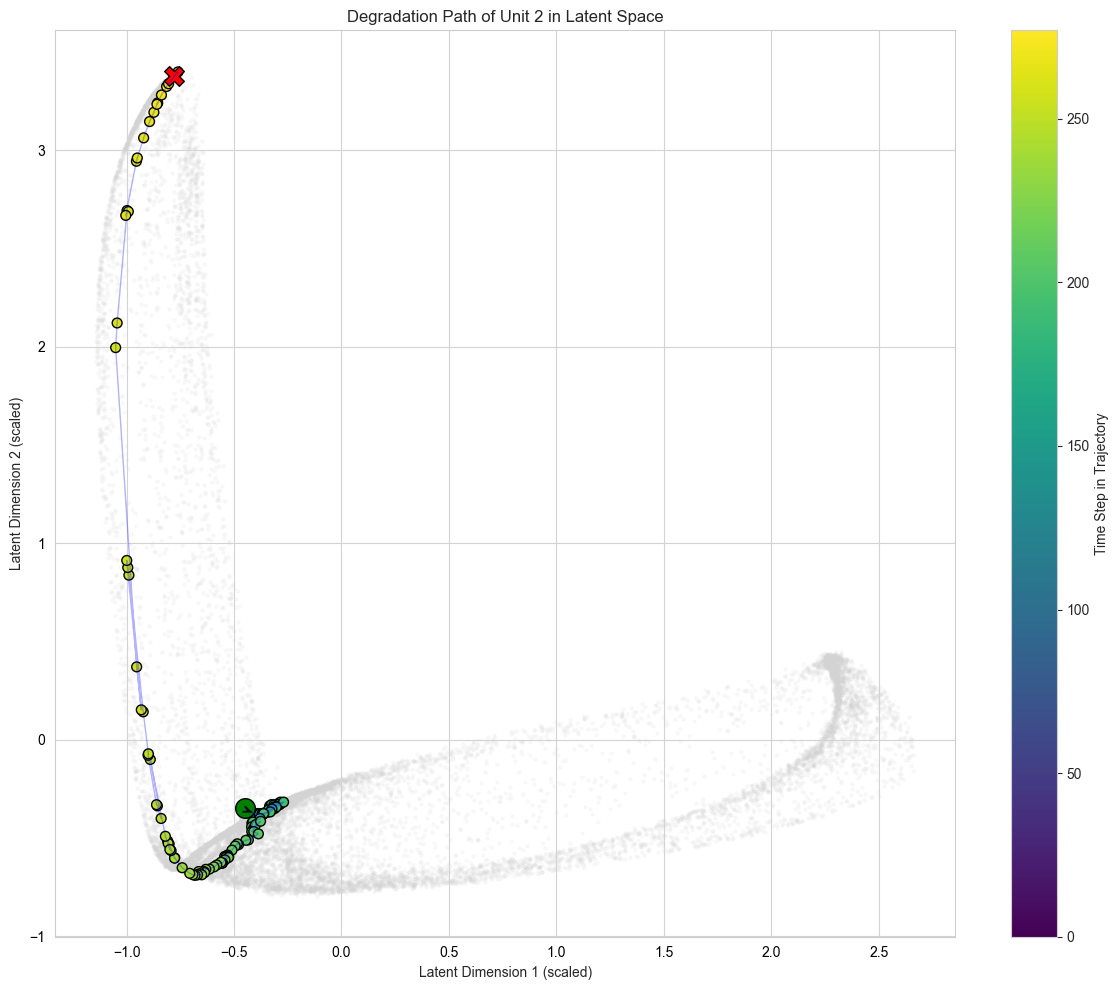


SCALING VERIFICATION:
Train latent range: (-2.98, 3.40)
Traj latent range: (-1.55, 3.40)


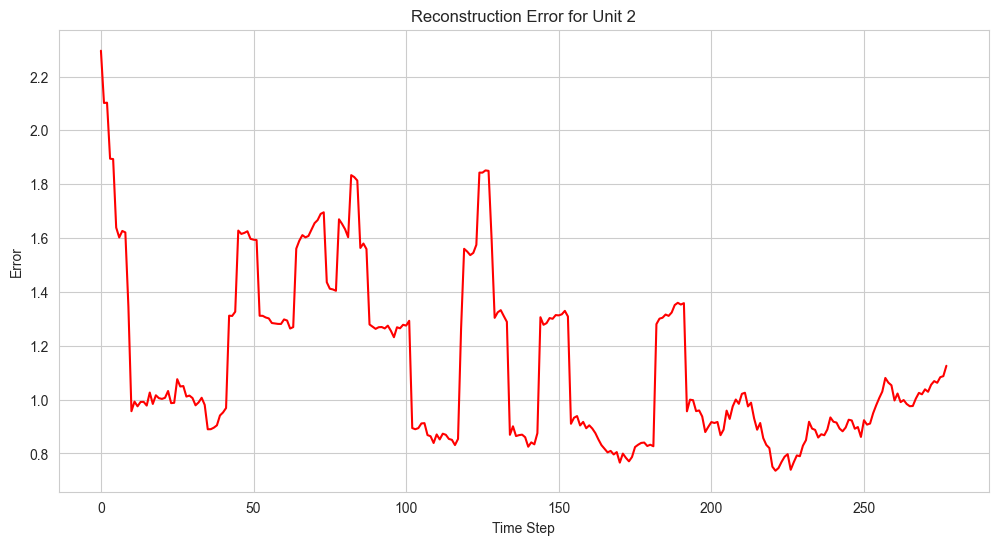

In [8]:
from CMAPSS.dataset import process_dataset
import matplotlib.pyplot as plt

# Create windows WITHOUT RUL as feature

# pick a unit_id to visualize and sample it
unit_id = 2
sample = process_dataset(dataset_train, unit_id=unit_id)

# Create windows for trajectory (same as training)
traj_windows, _, _ = create_windows(
    sample,
    window_size=window_size,
    threshold=-1  # Include all points
)

# Scale using SAME scaler
traj_windows_scaled = scaler.transform(traj_windows)

# _
with torch.no_grad():
    # Get latent vectors for training data
    z_traj = extract_latent_representations(model, traj_windows_scaled, device)
z_traj_scaled = scaler_z.transform(z_traj)

# Plot

plt.figure(figsize=(12, 10))
#plt.figure(facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')  # Set the axes background to white
ax.grid(True, color='lightgray')  # Ensure grid is visible
ax.tick_params(axis='both', colors='black')

# Plot training data as background
plt.scatter(z_train_scaled[:, 0], z_train_scaled[:, 1],
            c='lightgray', alpha=0.1, s=5, label='Training Data')

# Plot trajectory with color gradient
scatter = plt.scatter(z_traj_scaled[:, 0], z_traj_scaled[:, 1],
            c=np.arange(len(z_traj_scaled)),
            cmap='viridis', s=50, edgecolor='k',
            label=f'Unit {unit_id} Trajectory')

# Connect points with lines
plt.plot(z_traj_scaled[:, 0], z_traj_scaled[:, 1],
         'b-', alpha=0.3, linewidth=1)

# Add markers
plt.scatter(z_traj_scaled[0, 0], z_traj_scaled[0, 1],
            c='green', s=200, marker='o', edgecolor='k',
            label='Start (Healthy)')
plt.scatter(z_traj_scaled[-1, 0], z_traj_scaled[-1, 1],
            c='red', s=200, marker='X', edgecolor='k',
            label='End (Failure)')

# Add direction arrow
if len(z_traj_scaled) > 1:
    mid_point = len(z_traj_scaled) // 2
    plt.annotate('',
                xytext=(z_traj_scaled[mid_point-1, 0], z_traj_scaled[mid_point-1, 1]),
                xy=(z_traj_scaled[mid_point, 0], z_traj_scaled[mid_point, 1]),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5, alpha=0.8))

plt.colorbar(scatter, label='Time Step in Trajectory')
plt.title(f'Degradation Path of Unit {unit_id} in Latent Space')
plt.xlabel('Latent Dimension 1 (scaled)')
plt.ylabel('Latent Dimension 2 (scaled)')
#plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f'figures/{dataset_name}_z{latent_dim}_STEP.pdf', facecolor='white', bbox_inches='tight', dpi=200)

plt.show()

# 7. DIAGNOSTICS
print("\nSCALING VERIFICATION:")
print(f"Train latent range: ({z_train_scaled.min():.2f}, {z_train_scaled.max():.2f})")
print(f"Traj latent range: ({z_traj_scaled.min():.2f}, {z_traj_scaled.max():.2f})")

# Reconstruction error
model.eval()
with torch.no_grad():
    recon = model(torch.FloatTensor(traj_windows_scaled).to(device))[0].cpu().numpy()
errors = np.linalg.norm(abs(traj_windows_scaled - recon), axis=1)

plt.figure(figsize=(12, 6))
plt.plot(errors, 'r-')
plt.title(f'Reconstruction Error for Unit {unit_id}')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid(True)
plt.show()

# Downstream evaluation

In [9]:
from CMAPSS.degrad_analyzer import DegradationAnalyzer

# Initialize once
analyzer = DegradationAnalyzer(model, dataset_train, scaler, device, scaler_z=scaler_z, proto_size=latent_dim, window_size=window_size, scale=True)
progression_scaler = analyzer.fit_progression_scaler(method='angular') # unit_ids=[2, 5, 10, 15],

# Compute for all units (no plots)
all_data = analyzer.compute_all_progression_data(method='angular')

analyzer_test = DegradationAnalyzer(model, dataset_test, scaler, device, scaler_z=scaler_z, proto_size=latent_dim, window_size=window_size, progression_scaler=progression_scaler, scale=True)
all_data_test = analyzer_test.compute_all_progression_data(method='angular')

Fitting progression scaler on training data...


/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: divide by zero encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: overflow encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: invalid value encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: divide by zero encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: overflow encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0,

Fitted progression scaler on 19731 scores
Progression scaler's scale: 0.7037


/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: divide by zero encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: overflow encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: invalid value encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: divide by zero encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0, 1.0))
/Users/lucas-andreithil/PycharmProjects/STEP/CMAPSS/degrad_analyzer.py:304: RuntimeWarning: overflow encountered in matmul
  angles = np.arccos(np.clip(z_normalized @ initial_prototype, -1.0,

In [27]:
from models.downstream_head import benchmark_model

downstream_results = benchmark_model(
        all_data, all_data_test, dataset_test_RUL,
        feature_names=['progression_scores', 'z_latent',  'angles'],#, 'radii', 'progression_scores', 'z_latent'],
        model_type='transformer',
        smoothing_window=1,
    )

Test samples: (70, 1350), labels: (70,)
Test 3D shape: (70, 75, 18)
Using device: mps
Epoch [10/50], Train Loss: 218.0275, Test RMSE: 14.2669
Epoch [20/50], Train Loss: 208.2415, Test RMSE: 14.2926
Epoch [30/50], Train Loss: 204.5901, Test RMSE: 14.5590
Epoch [40/50], Train Loss: 190.7188, Test RMSE: 14.1579
Epoch [50/50], Train Loss: 191.5054, Test RMSE: 15.4725
Loaded best model from epoch 43 with test RMSE: 13.3219
Final Transformer Test RMSE: 13.3219
Final Transformer Test MAE: 9.9005
Final Transformer Test R²: 0.8662
